# 2. Statistical Filter Methods: Chi-Square, ANOVA F-Test, and Mutual Information

In Notebook 1, we filtered features **without looking at the target $y$** (unsupervised filtering like zero variance and collinearity).

In this notebook, we look at **Supervised Statistical Filters**. These techniques measure the mathematical relationship between each input feature ($X$) and the target outcome ($y$), ranking features from most informative to least informative.

### What We Will Cover:
1. **The Core Question**: How do we decide which statistical test fits our feature types?
2. **Chi-Square ($\chi^2$) Test**: For Categorical Feature vs. Categorical Target.
3. **ANOVA F-Test (`f_classif`)**: For Continuous/Numerical Feature vs. Categorical Target (captures linear variance separation).
4. **Mutual Information (`mutual_info_classif`)**: For Non-Linear dependencies using information theory (Entropy).
5. **Scikit-Learn Selectors**: Using `SelectKBest` and `SelectPercentile` to prune non-informative noise.

---
## Cheat Sheet: Which Statistical Test Do You Use?

The test you choose depends entirely on the data types of your feature ($X$) and your target ($y$):

| Feature Type ($X$) | Target Type ($y$) | Statistical Test to Use | Scikit-Learn Function | What It Detects |
| :--- | :--- | :--- | :--- | :--- |
| **Categorical** | Categorical | **Chi-Square ($\chi^2$)** | `chi2` | Tests if category distributions differ across target classes (frequencies). |
| **Continuous (Numerical)** | Categorical | **ANOVA F-Test** | `f_classif` | Compares the means of each class; assumes linear separation. |
| **Any (Continuous or Discrete)** | Categorical | **Mutual Information** | `mutual_info_classif` | Detects **any** relationship (linear OR complex non-linear curves) using entropy. |
| **Continuous (Numerical)** | Continuous (Regression) | **Correlation / F-Regression** | `f_regression` | Linear correlation for regression tasks. |

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2, f_classif, mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

np.random.seed(42)
n_samples = 1200

# 1. Generate realistic Customer Churn features
# Continuous features with genuine signal:
monthly_charges = np.random.normal(loc=70, scale=25, size=n_samples).clip(20, 150)
tenure_months = np.random.exponential(scale=20, size=n_samples).clip(1, 72)
support_tickets = np.random.poisson(lam=1.5, size=n_samples)

# Non-linear continuous feature (U-shaped risk: very low usage or very high usage causes churn)
data_usage_gb = np.random.uniform(5, 100, size=n_samples)
non_linear_churn_signal = ((data_usage_gb - 50) ** 2) / 600

# Categorical features with genuine signal:
contract_type = np.random.choice(['Month-to-Month', 'One-Year', 'Two-Year'], size=n_samples, p=[0.55, 0.25, 0.20])
payment_method = np.random.choice(['Electronic_Check', 'Credit_Card', 'Bank_Transfer'], size=n_samples, p=[0.4, 0.3, 0.3])

# 2. Inject PURE NOISE columns (These carry zero predictive relationship to churn)
noise_numerical_1 = np.random.normal(0, 1, size=n_samples)
noise_numerical_2 = np.random.uniform(100, 500, size=n_samples)
noise_categorical = np.random.choice(['Red', 'Blue', 'Green'], size=n_samples)

# 3. Calculate target probability (Customer Churn: 0 = Retained, 1 = Churned)
churn_logits = (
    0.02 * monthly_charges 
    - 0.05 * tenure_months 
    + 0.6 * support_tickets 
    + non_linear_churn_signal
    + (contract_type == 'Month-to-Month') * 1.2
    - (contract_type == 'Two-Year') * 1.5
    + (payment_method == 'Electronic_Check') * 0.5
    - 2.0
)
churn_prob = 1 / (1 + np.exp(-churn_logits))
churn_target = (np.random.rand(n_samples) < churn_prob).astype(int)

# Combine into clean tabular DataFrame
df = pd.DataFrame({
    'Monthly_Charges': monthly_charges,
    'Tenure_Months': tenure_months,
    'Support_Tickets': support_tickets,
    'Data_Usage_GB': data_usage_gb,
    'Noise_Num_1': noise_numerical_1,
    'Noise_Num_2': noise_numerical_2,
    'Contract_Type': contract_type,
    'Payment_Method': payment_method,
    'Noise_Cat': noise_categorical,
    'Churn': churn_target
})

print("=== RAW CUSTOMER CHURN DATASET (With Injected Noise Columns) ===")
print(f"Shape: {df.shape}")
display(df.head())
print("\nTarget Distribution:")
print(df['Churn'].value_counts(normalize=True).map('{:.1%}'.format))

=== RAW CUSTOMER CHURN DATASET (With Injected Noise Columns) ===
Shape: (1200, 10)


,Monthly_Charges,Tenure_Months,Support_Tickets,Data_Usage_GB,Noise_Num_1,Noise_Num_2,Contract_Type,Payment_Method,Noise_Cat,Churn
0,82.417854,1.000000,2,92.754483,0.595897,472.864688,One-Year,Electronic_Check,Blue,1
1,66.543392,20.056120,1,83.039769,0.943051,249.814461,Month-to-Month,Bank_Transfer,Blue,1
2,86.192213,60.484010,2,38.636133,-0.336866,132.311686,Month-to-Month,Credit_Card,Red,0
3,108.075746,18.406568,3,67.302973,1.522711,254.916469,Month-to-Month,Bank_Transfer,Green,1
4,64.146166,34.206044,0,56.041189,-0.785700,340.081019,Month-to-Month,Electronic_Check,Red,0



Target Distribution:
Churn
1    68.8%
0    31.2%
Name: proportion, dtype: object


---
## Step 1: Stratified Train / Test Split & Categorical Encoding

**Rule of Thumb**: Feature selection tests calculate statistics against $y$. If you compute these scores on the full dataset before splitting, information about the test targets leaks into your feature selection. Always split first.

In [3]:
from sklearn.compose import ColumnTransformer

X = df.drop(columns=['Churn']).copy()
y = df['Churn'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

ct = ColumnTransformer(transformers=[
    ('cpn_oe', OrdinalEncoder(), ['Contract_Type', 'Payment_Method', 'Noise_Cat'])
], remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')

X_train_encoded = ct.fit_transform(X_train)
X_test_encoded  = ct.transform(X_test)

print("Encoded Training Data Preview:")
display(X_train_encoded.head())

''' another simple way to write this is:
X = df.drop(columns=['Churn']).copy()
y = df['Churn'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Encode categorical features into non-negative integers (Required by Chi-Square)
cat_cols = ['Contract_Type', 'Payment_Method', 'Noise_Cat']
num_cols = ['Monthly_Charges', 'Tenure_Months', 'Support_Tickets', 'Data_Usage_GB', 'Noise_Num_1', 'Noise_Num_2']

encoder = OrdinalEncoder()
X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

print("Data encoded successfully. Ready for statistical tests.")
'''


Encoded Training Data Preview:


,Contract_Type,Payment_Method,Noise_Cat,Monthly_Charges,Tenure_Months,Support_Tickets,Data_Usage_GB,Noise_Num_1,Noise_Num_2
445,0.0,0.0,0.0,86.741814,2.908704,3,53.634170,-0.341647,478.075432
118,0.0,1.0,1.0,98.570570,4.676774,2,74.923363,-0.123693,379.462792
407,0.0,2.0,2.0,66.440513,54.095112,1,43.997378,-0.036377,478.913729
580,2.0,0.0,2.0,78.462410,42.729172,1,81.835947,-0.944128,447.736043
453,2.0,0.0,2.0,82.601163,5.673238,1,16.051514,2.311259,454.625645


' another simple way to write this is:\nX = df.drop(columns=[\'Churn\']).copy()\ny = df[\'Churn\'].copy()\n\nX_train, X_test, y_train, y_test = train_test_split(\n    X, y, test_size=0.20, random_state=42, stratify=y\n)\n\n# Encode categorical features into non-negative integers (Required by Chi-Square)\ncat_cols = [\'Contract_Type\', \'Payment_Method\', \'Noise_Cat\']\nnum_cols = [\'Monthly_Charges\', \'Tenure_Months\', \'Support_Tickets\', \'Data_Usage_GB\', \'Noise_Num_1\', \'Noise_Num_2\']\n\nencoder = OrdinalEncoder()\nX_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])\nX_test[cat_cols] = encoder.transform(X_test[cat_cols])\n\nprint("Data encoded successfully. Ready for statistical tests.")\n'

---
## Step 2: Chi-Square ($\chi^2$) Test for Categorical Features

### How it Works:
The Chi-Square test compares the **observed frequencies** of categories against the **expected frequencies** (what would happen if the feature and target had zero correlation).

$$\chi^2 = \sum \frac{(\text{Observed} - \text{Expected})^2}{\text{Expected}}$$

* **High $\chi^2$ Score (Low $p$-value)**: The category distribution differs significantly between churned and retained customers $\rightarrow$ **Keep Feature**.
* **Low $\chi^2$ Score (High $p$-value)**: The distribution is completely random across both classes $\rightarrow$ **Drop Feature**.
* *Requirement*: Chi-Square cannot accept negative numbers (values must be non-negative).

In [6]:
# Run Chi-Square test on categorical features
chi2_scores, chi2_pvalues = chi2(X_train_encoded[['Contract_Type', 'Payment_Method', 'Noise_Cat']], y_train)

df_chi2 = pd.DataFrame({
    'Feature': ['Contract_Type', 'Payment_Method', 'Noise_Cat'],
    'Chi2_Score': chi2_scores,
    'p_value': chi2_pvalues
}).sort_values(by='Chi2_Score', ascending=False).reset_index(drop=True)

print("=== CHI-SQUARE TEST RESULTS (Categorical Features) ===")
display(df_chi2)

# Notice how 'Noise_Cat' gets a very low Chi2 score and high p-value (> 0.05),
# while Contract_Type has a large score with a statistically significant p-value (< 0.001).

=== CHI-SQUARE TEST RESULTS (Categorical Features) ===


,Feature,Chi2_Score,p_value
0,Contract_Type,89.014029,3.920226e-21
1,Payment_Method,2.270900,1.318233e-01
2,Noise_Cat,0.001183,9.725675e-01


---
## Step 3: ANOVA F-Test for Continuous Features (`f_classif`)

### How it Works:
ANOVA (Analysis of Variance) checks whether the mean values of a numerical feature are significantly different across the target classes.

$$F = \frac{\text{Variance BETWEEN class groups}}{\text{Variance WITHIN class groups}}$$

* If churned customers have an average tenure of 8 months, while retained customers have an average tenure of 45 months, the between-group variance is huge $\rightarrow$ **High F-score, Keep Feature**.
* If both groups have identical distributions (like our noise columns), between-group variance is near zero $\rightarrow$ **Low F-score, Drop Feature**.

In [8]:
f_scores, f_pvalues = f_classif(X_train_encoded[['Monthly_Charges', 'Tenure_Months', 'Support_Tickets', 'Data_Usage_GB', 'Noise_Num_1', 'Noise_Num_2']], y_train)

df_anova = pd.DataFrame({
    'Feature': ['Monthly_Charges', 'Tenure_Months', 'Support_Tickets', 'Data_Usage_GB', 'Noise_Num_1', 'Noise_Num_2'],
    'F_Score': f_scores,
    'p_value': f_pvalues
}).sort_values(by='F_Score', ascending=False).reset_index(drop=True)

print("=== ANOVA F-TEST RESULTS (Continuous Features) ===")
display(df_anova)

# Notice: Tenure_Months, Support_Tickets, and Monthly_Charges rank at the top.
# Both Noise_Num_1 and Noise_Num_2 have negligible F-scores with non-significant p-values.


=== ANOVA F-TEST RESULTS (Continuous Features) ===


,Feature,F_Score,p_value
0,Tenure_Months,69.761988,2.327141e-16
1,Support_Tickets,35.940683,2.878239e-09
2,Monthly_Charges,9.521281,2.089347e-03
3,Data_Usage_GB,4.750899,2.952590e-02
4,Noise_Num_2,2.054783,1.520552e-01
5,Noise_Num_1,0.000107,9.917682e-01


---
## Step 4: Mutual Information (`mutual_info_classif`)

### Why Do We Need Mutual Information If We Have ANOVA?
ANOVA assumes a **linear** relationship. If a feature has a non-linear relationship (such as a U-curve, circle, or threshold behavior), ANOVA will assign it a low F-score and mistakenly discard it.

**Mutual Information (MI)** is based on information entropy:
$$\text{MI}(X; Y) = H(Y) - H(Y \mid X)$$
It measures: *"How many bits of uncertainty about $Y$ are removed if we observe feature $X$?"*

* $\text{MI} = 0$: $X$ and $Y$ are completely independent.
* $\text{MI} > 0$: $X$ shares information with $Y$, regardless of whether the pattern is linear, logarithmic, sinusoidal, or a complex curve.

=== MUTUAL INFORMATION SCORES (All Features) ===


,Feature,MI_Score
0,Data_Usage_GB,0.063895
1,Contract_Type,0.036422
2,Tenure_Months,0.029540
3,Payment_Method,0.018190
4,Support_Tickets,0.009400
5,Monthly_Charges,0.000000
6,Noise_Cat,0.000000
7,Noise_Num_1,0.000000
8,Noise_Num_2,0.000000


C:\Users\DEVA\AppData\Local\Temp\ipykernel_2916\3621907137.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_mi, x='MI_Score', y='Feature', palette='Blues_r')


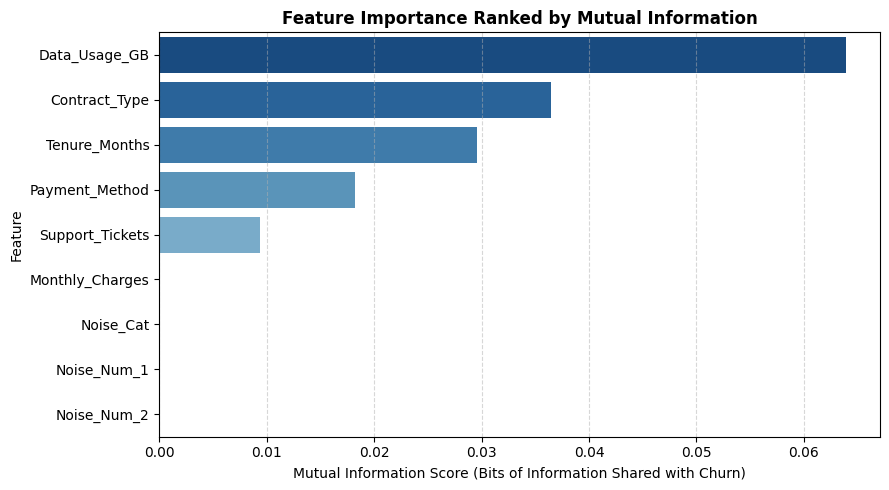

In [10]:
# Run Mutual Information across ALL features (both numerical and encoded categorical)
mi_scores = mutual_info_classif(X_train_encoded, y_train, random_state=42)

df_mi = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False).reset_index(drop=True)

print("=== MUTUAL INFORMATION SCORES (All Features) ===")
display(df_mi)

# Visualizing the ranking
plt.figure(figsize=(9, 5))
sns.barplot(data=df_mi, x='MI_Score', y='Feature', palette='Blues_r')
plt.title("Feature Importance Ranked by Mutual Information", fontsize=12, fontweight='bold')
plt.xlabel("Mutual Information Score (Bits of Information Shared with Churn)")
plt.ylabel("Feature")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Key Observation: Look at Data_Usage_GB. ANOVA ranked it lower due to its non-linear curve,
# but Mutual Information successfully detected its strong predictive dependency!

---
## Step 5: Automated Filtering with `SelectKBest` and Model Evaluation

Instead of manually slicing columns, we use Scikit-Learn's `SelectKBest` with `mutual_info_classif` to keep the top 5 most informative features and automatically drop the 3 noise columns.

In [13]:
# 1. Initialize selector to retain the top 5 features using Mutual Information
selector = SelectKBest(score_func=mutual_info_classif, k=5)

# Fit on train, transform train and test
X_train_selected = selector.fit_transform(X_train_encoded, y_train)
X_test_selected = selector.transform(X_test_encoded)

selected_mask = selector.get_support()
retained_columns = X_train_encoded.columns[selected_mask]
dropped_columns = X_train_encoded.columns[~selected_mask]

print(f"Retained Features ({len(retained_columns)}): {list(retained_columns)}")
print(f"Dropped Noise Features ({len(dropped_columns)}): {list(dropped_columns)}")

# 2. Benchmark Downstream Classifier: All 9 Features vs. Selected 5 Features
rf_sel = RandomForestClassifier(random_state=42).fit(X_train_encoded, y_train)
y_pred_all = rf_sel.predict(X_test_encoded)

rf_sel = RandomForestClassifier(random_state=42).fit(X_train_selected, y_train)
y_pred_sel = rf_sel.predict(X_test_selected)

print("\n=== PERFORMANCE ON FULL FEATURE SET (Includes Noise) ===")
print(classification_report(y_test, y_pred_all, target_names=['Retained (0)', 'Churned (1)']))

print("=== PERFORMANCE ON STATISTICALLY FILTERED SUBSET (Noise Pruned) ===")
print(classification_report(y_test, y_pred_sel, target_names=['Retained (0)', 'Churned (1)']))


Retained Features (5): ['Contract_Type', 'Noise_Cat', 'Tenure_Months', 'Support_Tickets', 'Data_Usage_GB']
Dropped Noise Features (4): ['Payment_Method', 'Monthly_Charges', 'Noise_Num_1', 'Noise_Num_2']

=== PERFORMANCE ON FULL FEATURE SET (Includes Noise) ===
              precision    recall  f1-score   support

Retained (0)       0.78      0.51      0.61        75
 Churned (1)       0.81      0.93      0.87       165

    accuracy                           0.80       240
   macro avg       0.79      0.72      0.74       240
weighted avg       0.80      0.80      0.79       240

=== PERFORMANCE ON STATISTICALLY FILTERED SUBSET (Noise Pruned) ===
              precision    recall  f1-score   support

Retained (0)       0.71      0.52      0.60        75
 Churned (1)       0.81      0.90      0.85       165

    accuracy                           0.78       240
   macro avg       0.76      0.71      0.73       240
weighted avg       0.78      0.78      0.77       240



---
## Practical Summary & When to Use Which

1. **Use Chi-Square (`chi2`)**: When you have sparse or dense one-hot/categorical inputs and want a fast statistical significance check against discrete classes.
2. **Use ANOVA (`f_classif`)**: When your dataset is large, predominantly linear, and you need a fast numerical ranking filter.
3. **Use Mutual Information (`mutual_info_classif`)**: When you suspect complex, non-linear relationships that linear tests miss. It is slightly slower to compute because it uses $k$-NN distance calculations, but it captures both linear and non-linear patterns reliably.